In [1]:
import pandas as pd

# df_raw = pd.read_excel(r'../data/credit_risk_dataset_v2_sample10k.xlsx', sheet_name='Customer Data')
# switched to parquet for faster loading
df_raw = pd.read_parquet(r'../data/credit_risk_dataset_v2.parquet')
print(df_raw.shape)

(100000, 538)


In [2]:
df_raw.head(5)

,customer_id,risk_attribute_770487,risk_attribute_216739,risk_attribute_126225,risk_attribute_877572,risk_attribute_388389,risk_attribute_356787,risk_attribute_334053,risk_attribute_246316,risk_attribute_872246,...,risk_attribute_815198,risk_attribute_361650,risk_attribute_799330,risk_attribute_207786,risk_attribute_470858,risk_attribute_918011,risk_attribute_687080,risk_attribute_526117,risk_attribute_750810,risk_attribute_885884
0,CUST_0000001,0,0,0,0,0,0,0,0,0,...,3,129040,0,1.2165,0,5,600,0,28,0
1,CUST_0000002,83,16,27,44,88,18,21,95,60,...,7,209523,31881,2.0054,2,3,8,1,27,0
2,CUST_0000003,0,0,0,0,0,0,0,0,0,...,6,291204,16642,2.1153,0,5,600,1,31,0
3,CUST_0000004,0,0,0,0,0,0,0,0,0,...,4,124421,242679,1.1624,0,5,600,2,62,0
4,CUST_0000005,0,0,0,0,0,0,0,0,0,...,2,122404,102981,0.0000,0,5,600,1,67,0


In [3]:
#target columns
# a customer flagged `bad = 1` if any of three risk attributes cross a threshold (one ≥ 8, two others > 0), else `0`
df_raw['bad'] = (
    (df_raw['risk_attribute_383060'] >= 8) |
    (df_raw['risk_attribute_274389'] > 0) |
    (df_raw['risk_attribute_272634'] > 0)
).astype(int)
#  value_counts and mean show the class balance and the resulting bad rate.
print(df_raw['bad'].value_counts())
print("Bad rate:", df_raw['bad'].mean())
# the three columns used to *build* the label are stored in `leakage_cols` and dropped from the features otherwise the model could cheat by learning the exact rule that defined the target. `customer_id` (an identifier, not a predictor) is also dropped.
leakage_cols = ['risk_attribute_383060', 'risk_attribute_274389', 'risk_attribute_272634']
X = df_raw.drop(columns=['customer_id', 'bad'] + leakage_cols)
y = df_raw['bad']
# The result is `X` (features) and `y` (target). The final line confirms there are no missing values.
print("X shape:", X.shape, "y shape:", y.shape)
print("Missing Values in dataset:", X.isnull().sum().sum())

bad
0    98552
1     1448
Name: count, dtype: int64
Bad rate: 0.01448
X shape: (100000, 534) y shape: (100000,)
Missing Values in dataset: 0


In [4]:
#train test split 80/20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(80000, 534) (20000, 534)
0.014475 0.0145


In [5]:
# --- imports + shared setup ---
# The baseline model cells were removed, which took these imports (and `spw`) with them.
# This cell restores what the rest of the notebook depends on.
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV,
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix,
)

# used by the leakage sweep below
spw = (y == 0).sum() / (y == 1).sum()
print("scale_pos_weight (original label):", round(spw, 2))

scale_pos_weight (original label): 68.06


In [6]:
# dd = pd.read_excel(r'../data/credit_risk_dataset_v2_sample10k.xlsx', sheet_name='Data Dictionary')
# col2cat = dd.set_index('Column Name')['Category'].to_dict()
# col2def = dd.set_index('Column Name')['Definition'].to_dict()
# print(dd.shape)
# print(dd['Category'].value_counts().head(15).to_string())

dd = pd.read_parquet(r'../data/credit_risk_data_dictionary.parquet')
col2cat = dd.set_index('Column Name')['Category'].to_dict()
col2def = dd.set_index('Column Name')['Definition'].to_dict()

In [7]:
# What the three label-source columns
for c in leakage_cols:
    print(f"{c}\n  category: {col2cat[c]}\n  def     : {col2def[c]}\n")

c = 'risk_attribute_671412'
print(f"{c}\n  category: {col2cat[c]}\n  def     : {col2def[c]}")

risk_attribute_383060
  category: Worst Status Codes
  def     : Worst status code ever on a all trades

risk_attribute_274389
  category: Collections and Derogatory Metrics
  def     : Total number of charge-off trades

risk_attribute_272634
  category: Public Records and Bankruptcy
  def     : Total number of public record bankruptcies

risk_attribute_671412
  category: Delinquency Percentages
  def     : Percentage of all trades that are never delinquent or derogatory


In [8]:
# how much to remove before the label stops being reconstructible?
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

single_auc = {}
for c in X.columns:
    if X[c].nunique() < 2:
        continue
    a = roc_auc_score(y, X[c])
    single_auc[c] = max(a, 1 - a)
single_auc = pd.Series(single_auc)

rows = []
for thr in [0.95, 0.90, 0.80, 0.70, 0.60, 0.55]:
    drop = single_auc[single_auc > thr].index
    Xd = X.drop(columns=drop)
    a, b, c_, d = train_test_split(Xd, y, test_size=.2, random_state=42, stratify=y)
    mm = XGBClassifier(n_estimators=300, learning_rate=.05, max_depth=4, subsample=.8,
                       colsample_bytree=.8, min_child_weight=5, scale_pos_weight=spw,
                       eval_metric='aucpr', random_state=42, n_jobs=-1).fit(a, c_)
    pp = mm.predict_proba(b)[:, 1]
    rows.append({'drop_above_auc': thr, 'n_dropped': len(drop), 'n_left': Xd.shape[1],
                 'roc_auc': roc_auc_score(d, pp), 'pr_auc': average_precision_score(d, pp)})

print(pd.DataFrame(rows).round(4).to_string(index=False))

 drop_above_auc  n_dropped  n_left  roc_auc  pr_auc
           0.95         19     515   1.0000  1.0000
           0.90        138     396   1.0000  1.0000
           0.80        318     216   0.9996  0.9943
           0.70        418     116   0.9864  0.6954
           0.60        475      59   0.8227  0.3661
           0.55        521      13   0.6251  0.1412


In [9]:
# --- feature filter (corrected) ---
# The previous version of this cell had two bugs, both of which inflated PR-AUC to 0.917:
#
#   1. `bad` (the original 3-event label, written into df_raw by the label cell) survived
#      the filter, because col2cat.get('bad') is None and None is not in the category set.
#      It was the #2 feature at 14.6% of gain. `bad` is 1 whenever bankruptcy is 1.
#
#   2. Category labels do not track content. "Total dollar amount in derogatory status"
#      is filed under Balance Metrics; "trade types with at least one delinquency ever"
#      under Miscellaneous. 47 such columns passed the category filter.
#
# Fix: filter on definition TEXT as well as category, and drop anything that is not a
# documented bureau attribute.
import re

TARGET_COL = 'risk_attribute_272634'   # total public record bankruptcies

DEROGATORY_CATEGORIES = {
    'Delinquency Percentages',
    'Delinquency Counts – 30 Days',
    'Delinquency Counts – 60 Days and Severe',
    'Worst Status Codes',
    'Collections and Derogatory Metrics',
    'Months Since Delinquency',
    'Public Records and Bankruptcy',
    'Additional Delinquency Severity and Recurrence',
    'Derived and Composite Risk Indicators',
    'Financial Stress and Hardship Indicators',
    'Payment History and Behavior',
}

DEROG_TERMS = re.compile(
    r'delinq|derog|charge[ -]?off|charged[ -]?off|collection|bankrupt|public record|'
    r'dispute|repossess|foreclos|written[ -]off|past due|\bdpd\b|worst status|'
    r'ever 30|ever 60|ever 90|ever 120|30\+|60\+|90\+',
    re.I,
)

# "excluding derogatory" is a scope qualifier, not derogatory content. It still leaks
# indirectly: the model can difference such a column against its unqualified twin to
# recover the derogatory amount. Set to False to keep them and see how much it matters.
DROP_SCOPE_QUALIFIED = True
SCOPE = re.compile(r'\b(?:excluding|excl\.?|except|other than)\b[^,;.]*', re.I)

_txt = (dd['Definition'].fillna('') + ' | ' + dd['Valid Values / Notes'].fillna(''))
_content = _txt.apply(lambda t: bool(DEROG_TERMS.search(SCOPE.sub(' ', t))))
_scope   = _txt.apply(lambda t: bool(DEROG_TERMS.search(t))) & ~_content

content_cols = set(dd.loc[_content, 'Column Name'])
scope_cols   = set(dd.loc[_scope,   'Column Name'])
documented   = set(dd['Column Name'])          # anything not here is not a bureau attribute

y_v2 = (df_raw[TARGET_COL] > 0).astype(int)

dropped = {'not a documented attribute': [], 'derogatory category': [],
           'derogatory in definition': [], 'scope-qualified': []}
clean_cols = []
for c in df_raw.columns:
    if c not in documented:                       # customer_id, bad, anything else added
        dropped['not a documented attribute'].append(c)
    elif col2cat.get(c) in DEROGATORY_CATEGORIES:
        dropped['derogatory category'].append(c)
    elif c in content_cols:
        dropped['derogatory in definition'].append(c)
    elif c in scope_cols and DROP_SCOPE_QUALIFIED:
        dropped['scope-qualified'].append(c)
    else:
        clean_cols.append(c)

X_v2 = df_raw[clean_cols]

for reason, cols in dropped.items():
    print(f"dropped ({reason}): {len(cols)}")
    if reason == 'not a documented attribute':
        print(f"    -> {cols}")
print(f"\nfeatures kept: {X_v2.shape[1]}   (previous buggy run: 309)")
print(f"positives: {int(y_v2.sum())}   rate: {y_v2.mean():.4f}")

assert 'bad' not in X_v2.columns, "label leaked into features"
assert TARGET_COL not in X_v2.columns, "target leaked into features"
print("\nassertions passed")

dropped (not a documented attribute): 2
    -> ['customer_id', 'bad']
dropped (derogatory category): 229
dropped (derogatory in definition): 47
dropped (scope-qualified): 50

features kept: 211   (previous buggy run: 309)
positives: 648   rate: 0.0065

assertions passed


In [10]:
# --- residual leakage audit ---
# Run this BEFORE trusting any score.
#
# Scored on average precision (PR-AUC), NOT ROC-AUC. At a 0.65% base rate a feature can
# reach ROC-AUC 0.95 while carrying almost no precision — the earlier version of this cell
# thresholded on ROC-AUC and raised a false alarm on ordinary credit-age features.
#
# Reference points at this base rate:
#   AP ~ 0.006  = random
#   AP ~ 0.02-0.06 = ordinary weak predictor (expected here)
#   AP > 0.25   = suspiciously strong for a single column; read its definition
#   AP > 0.50   = almost certainly leakage; extend DEROG_TERMS and re-run
floor_v2 = y_v2.mean()

rows = []
for c in X_v2.columns:
    v = X_v2[c]
    if v.nunique() < 2:
        continue
    # direction-agnostic: try the column and its negation, keep the better
    ap = max(average_precision_score(y_v2, v), average_precision_score(y_v2, -v))
    roc = roc_auc_score(y_v2, v)
    rows.append({"feature": c, "avg_precision": ap, "lift": ap / floor_v2,
                 "roc_auc": max(roc, 1 - roc)})

audit = (pd.DataFrame(rows)
         .sort_values("avg_precision", ascending=False)
         .set_index("feature"))
audit["category"] = [col2cat.get(c) for c in audit.index]
audit["definition"] = [str(col2def.get(c))[:60] for c in audit.index]

print(f"random-guessing floor: {floor_v2:.4f}\n")
print("top 10 single features by average precision:\n")
print(audit.head(10).round(4).to_string())

worst_ap = audit["avg_precision"].iloc[0]
print(f"\nmax single-feature AP: {worst_ap:.4f}  ({worst_ap / floor_v2:.1f}x floor)")
if worst_ap > 0.50:
    print("  -> LEAKING. One column nearly determines the target.")
    print("     Read its definition, extend DEROG_TERMS, re-run.")
elif worst_ap > 0.25:
    print("  -> Suspiciously strong. Read the top definitions before trusting results.")
else:
    print("  -> No single column dominates. Reasonable to proceed.")

# ROC-AUC shown for context only. High ROC with low AP is normal under heavy imbalance
# and is NOT evidence of leakage.
print(f"\n(for context) max single-feature ROC-AUC: {audit['roc_auc'].max():.4f}"
      "  — expected to be high here; not a leakage signal on its own")

random-guessing floor: 0.0065

top 10 single features by average precision:

                       avg_precision     lift  roc_auc                                    category                                                    definition
feature                                                                                                                                                         
risk_attribute_122056         0.0838  12.9262   0.9436                             Inquiry Metrics  Range of days between the first and last inquiry made in the
risk_attribute_216970         0.0833  12.8540   0.9501               Credit Age and History Length  Average number of months since credit card trades were opene
risk_attribute_103717         0.0799  12.3366   0.9436       Credit File Characteristics and Flags  Percentage of trades with balance-to-limit ratio above 30% (
risk_attribute_716886         0.0799  12.3267   0.9425                             Inquiry Metrics  Average number of 

In [11]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)
spw_v2 = (y2_train == 0).sum() / (y2_train == 1).sum()

xgb_v2 = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.6,
    min_child_weight=10,
    reg_lambda=5.0,
    scale_pos_weight=spw_v2,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)
xgb_v2.fit(X2_train, y2_train)

proba_v2 = xgb_v2.predict_proba(X2_test)[:, 1]
pr = average_precision_score(y2_test, proba_v2)
floor = y2_test.mean()

print("ROC-AUC : %.4f" % roc_auc_score(y2_test, proba_v2))
print("PR-AUC  : %.4f" % pr)
print("Floor   : %.4f  (random guessing)" % floor)
print("Lift    : %.1fx over random" % (pr / floor))

ROC-AUC : 0.9700
PR-AUC  : 0.1110
Floor   : 0.0065  (random guessing)
Lift    : 17.1x over random


In [12]:
# Cross-validated only around 15 positives land in a single test split, so one number is unreliable.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_v2 = cross_val_score(xgb_v2, X_v2, y_v2, cv=cv, scoring="average_precision", n_jobs=-1)

print("Fold PR-AUCs:", np.round(cv_v2, 4))
print("Mean: %.4f  (+/- %.4f)" % (cv_v2.mean(), cv_v2.std()))

Fold PR-AUCs: [0.0945 0.1151 0.1194 0.1102 0.0947]
Mean: 0.1068  (+/- 0.0104)


Best-F1 threshold: 0.7993
  precision 0.125   recall 0.662   F1 0.210


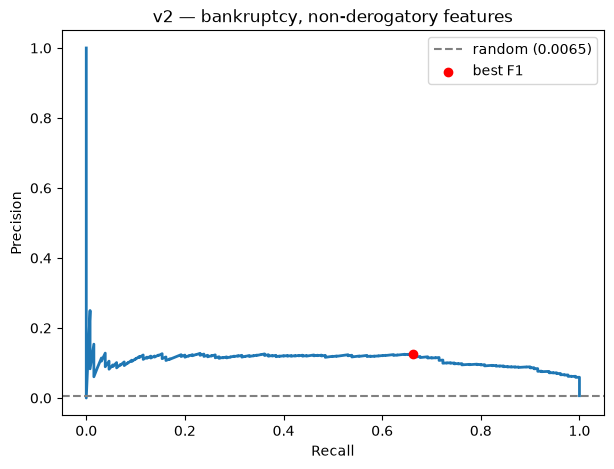

[[19267   603]
 [   44    86]]
              precision    recall  f1-score   support

           0      0.998     0.970     0.983     19870
           1      0.125     0.662     0.210       130

    accuracy                          0.968     20000
   macro avg      0.561     0.816     0.597     20000
weighted avg      0.992     0.968     0.978     20000



In [13]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

prec, rec, thresh = precision_recall_curve(y2_test, proba_v2)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best = f1.argmax()

print("Best-F1 threshold: %.4f" % thresh[min(best, len(thresh) - 1)])
print("  precision %.3f   recall %.3f   F1 %.3f" % (prec[best], rec[best], f1[best]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, lw=2)
ax.axhline(floor, ls="--", c="grey", label="random (%.4f)" % floor)
ax.scatter(rec[best], prec[best], c="red", zorder=5, label="best F1")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("v2 — bankruptcy, non-derogatory features")
ax.legend(); plt.show()

pred_v2 = (proba_v2 >= thresh[min(best, len(thresh) - 1)]).astype(int)
print(confusion_matrix(y2_test, pred_v2))
print(classification_report(y2_test, pred_v2, digits=3))

In [14]:
imp_v2 = pd.Series(xgb_v2.feature_importances_, index=X_v2.columns).sort_values(ascending=False)

top = pd.DataFrame({
    "gain": imp_v2.head(15).round(4),
    "category": [col2cat.get(c) for c in imp_v2.head(15).index],
    "definition": [str(col2def.get(c))[:70] for c in imp_v2.head(15).index],
})
print("top-1 share of gain: %.1f%%  (baseline was 37.7%%)" % (100 * imp_v2.iloc[0] / imp_v2.sum()))
print(top.to_string())

top-1 share of gain: 12.1%  (baseline was 37.7%)
                         gain                                    category                                                              definition
risk_attribute_216970  0.1209               Credit Age and History Length  Average number of months since credit card trades were opened includin
risk_attribute_299122  0.0739              Liquidity and Capacity Metrics  Number of months of liquidity: ratio of total unused credit to total m
risk_attribute_595948  0.0597                 Auto Loan and Lease Metrics         Number of months since the most recently opened auto loan trade
risk_attribute_564656  0.0518            Credit Card and Bankcard Metrics  Percentage of open credit card trades where only minimum payment was m
risk_attribute_178898  0.0266  Supplemental Bankcard and Revolving Detail  Number of months since the last time consumer had zero balance on all 
risk_attribute_265840  0.0261               Credit Age and History Length  

In [15]:
#hyperparameter search
from scipy.stats import loguniform, randint, uniform

USE_GPU = False   # set True if you have an NVIDIA GPU
N_CANDIDATES = 100
N_JOBS = 14        # set to your physical core count, not -1

base = XGBClassifier(
    eval_metric="aucpr",
    random_state=42,
    tree_method="hist",
    device="cuda" if USE_GPU else "cpu",
    n_jobs=1,     
)

param_dist = {
    "n_estimators":     randint(200, 1200),
    "learning_rate":    loguniform(0.01, 0.2),
    "max_depth":        randint(2, 7),
    "min_child_weight": randint(1, 30),
    "subsample":        uniform(0.6, 0.4),      # 0.6 - 1.0
    "colsample_bytree": uniform(0.3, 0.7),      # 0.3 - 1.0
    "reg_lambda":       loguniform(0.1, 50.0),
    "reg_alpha":        loguniform(1e-3, 10.0),
    "gamma":            loguniform(1e-4, 5.0),
    # searched, not fixed at n_neg/n_pos
    "scale_pos_weight": loguniform(1.0, spw_v2 * 2),
}

search = RandomizedSearchCV(
    base,
    param_distributions=param_dist,
    n_iter=N_CANDIDATES,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=69),
    n_jobs=N_JOBS,
    refit=True,
    random_state=69,
    verbose=1,
    return_train_score=False,
)

search.fit(X2_train, y2_train)   # test set deliberately untouched

print("\nbest CV PR-AUC: %.4f" % search.best_score_)
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:18} {v:.4f}" if isinstance(v, float) else f"  {k:18} {v}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

best CV PR-AUC: 0.1265
  colsample_bytree   0.4140
  gamma              0.0406
  learning_rate      0.0146
  max_depth          2
  min_child_weight   29
  n_estimators       303
  reg_alpha          0.0161
  reg_lambda         11.9453
  scale_pos_weight   5.9677
  subsample          0.9913


In [16]:
xgb_tuned = search.best_estimator_
proba_tuned = xgb_tuned.predict_proba(X2_test)[:, 1]

pr_v2    = average_precision_score(y2_test, proba_v2)
pr_tuned = average_precision_score(y2_test, proba_tuned)
floor    = y2_test.mean()

results = pd.DataFrame([
    {"model": "v2 (hand-tuned)", "cv_pr_auc": cv_v2.mean(),
     "heldout_pr_auc": pr_v2,    "heldout_roc_auc": roc_auc_score(y2_test, proba_v2)},
    {"model": "v2 (searched)",   "cv_pr_auc": search.best_score_,
     "heldout_pr_auc": pr_tuned, "heldout_roc_auc": roc_auc_score(y2_test, proba_tuned)},
])
results["lift_vs_random"] = (results["heldout_pr_auc"] / floor).round(1)
results["cv_minus_heldout"] = (results["cv_pr_auc"] - results["heldout_pr_auc"]).round(4)

print("random-guessing floor: %.4f\n" % floor)
print(results.round(4).to_string(index=False))

gap = search.best_score_ - pr_tuned
print("\nwinner's-curse gap: %+.4f" % gap)
if gap > 2 * cv_v2.std():
    print("CV score is optimistic by more than 2 CV std devs.")
    print("Report the held-out number, not best_score_.")
if pr_tuned <= pr_v2:
    print("Search did NOT beat the hand-tuned model on held-out data.")
    print("Expected on the 10k sample. Keep the simpler model.")

random-guessing floor: 0.0065

          model  cv_pr_auc  heldout_pr_auc  heldout_roc_auc  lift_vs_random  cv_minus_heldout
v2 (hand-tuned)     0.1068          0.1110             0.97            17.1           -0.0042
  v2 (searched)     0.1265          0.1172             0.97            18.0            0.0093

winner's-curse gap: +0.0093


In [17]:
#search surface flatness
cvres = pd.DataFrame(search.cv_results_)
top = cvres.nsmallest(20, "rank_test_score")[
    ["rank_test_score", "mean_test_score", "std_test_score",
     "param_max_depth", "param_min_child_weight", "param_scale_pos_weight",
     "param_learning_rate", "param_reg_lambda"]
]
print(top.round(4).to_string(index=False))

spread = top["mean_test_score"].max() - top["mean_test_score"].min()
print("\nspread across top-20: %.4f   typical fold std: %.4f"
      % (spread, top["std_test_score"].mean()))
if spread < top["std_test_score"].mean():
    print("Top-20 are within noise of each other; ranking not meaningful.")

 rank_test_score  mean_test_score  std_test_score  param_max_depth  param_min_child_weight  param_scale_pos_weight  param_learning_rate  param_reg_lambda
               1           0.1265          0.0176                2                      29                  5.9677               0.0146           11.9453
               2           0.1222          0.0179                2                      13                  2.7130               0.0130           15.5329
               3           0.1200          0.0108                2                       5                 17.0331               0.0252            0.9449
               4           0.1187          0.0142                6                      26                268.8300               0.0148            0.2263
               5           0.1184          0.0131                2                       3                  1.7830               0.0106            5.9953
               6           0.1172          0.0094                6          

In [ ]:
# --- export the model for use outside this notebook ---
#
# Saved as XGBoost's native JSON, not a joblib/pickle. Pickles embed Python class paths
# and break across xgboost/sklearn versions; the JSON format is version-stable, portable
# to the C++/Java/R APIs, and readable.
#
# The metadata file matters as much as the model. XGBoost matches features POSITIONALLY,
# so a caller that passes the same columns in a different order gets confident nonsense
# rather than an error. Feature order, dtypes, and the decision threshold all have to
# travel with the model.
import json, platform
from datetime import datetime, timezone
from pathlib import Path

import sklearn
import xgboost

EXPORT_DIR = Path("../exports")
EXPORT_DIR.mkdir(exist_ok=True)

# Prefer the searched model if the search cell has been run, else the hand-tuned one.
if "xgb_tuned" in dir():
    model, model_name, proba_export = xgb_tuned, "v3_searched", proba_tuned
else:
    model, model_name, proba_export = xgb_v2, "v3_hand_tuned", proba_v2

# Recompute the operating point for whichever model is being exported.
_prec, _rec, _thresh = precision_recall_curve(y2_test, proba_export)
_f1 = 2 * _prec * _rec / (_prec + _rec + 1e-9)
_b = _f1.argmax()
threshold = float(_thresh[min(_b, len(_thresh) - 1)])

model_path = EXPORT_DIR / f"{model_name}.json"
meta_path  = EXPORT_DIR / f"{model_name}_metadata.json"

model.get_booster().save_model(str(model_path))

metadata = {
    "model_name": model_name,
    "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "task": "binary classification",

    # predictions
    "target": {
        "column": TARGET_COL,
        "definition": "public record bankruptcies > 0",
        "positive_rate": float(y_v2.mean()),
    },

    #exact order expected at inference time.
    "feature_names": list(X_v2.columns),
    "n_features": int(X_v2.shape[1]),
    "feature_dtypes": {c: str(X_v2[c].dtype) for c in X_v2.columns},

    # scale_pos_weight has reshaped the probabilities.
    "decision_threshold": threshold,
    "threshold_basis": "max F1 on held-out test set",

    "metrics_heldout": {
        "pr_auc": float(average_precision_score(y2_test, proba_export)),
        "roc_auc": float(roc_auc_score(y2_test, proba_export)),
        "random_floor": float(y2_test.mean()),
        "precision_at_threshold": float(_prec[_b]),
        "recall_at_threshold": float(_rec[_b]),
    },
    "cv_pr_auc_mean": float(cv_v2.mean()),
    "cv_pr_auc_std": float(cv_v2.std()),

    "hyperparameters": {k: (v.item() if hasattr(v, "item") else v)
                        for k, v in model.get_params().items()
                        if v is not None and not callable(v)},

    "feature_filter": {
        "derogatory_categories_excluded": sorted(DEROGATORY_CATEGORIES),
        "drop_scope_qualified": bool(DROP_SCOPE_QUALIFIED),
        "note": ("Derogatory and delinquency attributes were deliberately removed. "
                 "This model scores bankruptcy risk from capacity and behaviour "
                 "attributes only."),
    },

    "limitations": [
        "Target is a synthetic label derived from a contemporaneous bureau snapshot, "
        "not an observed forward-looking default.",
        "No time separation exists between features and label; some features reflect "
        "the aftermath of bankruptcy rather than predicting it.",
        "Not suitable for credit decisions. Coursework artifact.",
    ],

    "environment": {
        "xgboost": xgboost.__version__,
        "scikit_learn": sklearn.__version__,
        "python": platform.python_version(),
    },
}

meta_path.write_text(json.dumps(metadata, indent=2))

print(f"model    -> {model_path}  ({model_path.stat().st_size / 1024:.0f} KB)")
print(f"metadata -> {meta_path}")
print(f"\nfeatures: {metadata['n_features']}   threshold: {threshold:.4f}")
print(f"heldout PR-AUC: {metadata['metrics_heldout']['pr_auc']:.4f}")

model    -> ..\exports\v3_searched.json  (233 KB)
metadata -> ..\exports\v3_searched_metadata.json

features: 211   threshold: 0.3582
heldout PR-AUC: 0.1172


In [ ]:
# verify the export round-trips
# Load the saved model as a bare Booster, mimicking a separate process, and confirm
# predictions match the in-memory model exactly. If this fails, do not ship the export.
import numpy as np
import xgboost as xgb

meta = json.loads(meta_path.read_text())
booster = xgb.Booster()
booster.load_model(str(model_path))

X_check = X2_test[meta["feature_names"]].astype(np.float32)
dm = xgb.DMatrix(X_check, feature_names=meta["feature_names"])
proba_reloaded = booster.predict(dm)

max_diff = np.abs(proba_reloaded - proba_export).max()
print(f"max probability difference: {max_diff:.3e}")
assert max_diff < 1e-5, "reloaded model disagrees with in-memory model"

pred_reloaded = (proba_reloaded >= meta["decision_threshold"]).astype(int)
pred_original = (proba_export     >= meta["decision_threshold"]).astype(int)
print(f"label disagreements: {(pred_reloaded != pred_original).sum()} of {len(pred_original)}")

#how well does the saved model defend itself against bad input
rng = np.random.default_rng(0)
shuffled = list(meta["feature_names"])
rng.shuffle(shuffled)

# Case 1: names supplied but in the wrong order. The native JSON stores feature names,
try:
    booster.predict(xgb.DMatrix(X2_test[shuffled].astype(np.float32)))
    print("\n[case 1] wrong order, named   -> NO ERROR (unexpected)")
except ValueError as e:
    print(f"\n[case 1] wrong order, named   -> ValueError raised (good): {str(e)[:60]}...")

# Case 2: THE DANGEROUS ONE. Values assembled in the wrong order but labelled with the
# correct names. Nothing can detect this - the model returns confident nonsense.
dm_lying = xgb.DMatrix(X2_test[shuffled].astype(np.float32).values,
                       feature_names=meta["feature_names"])
proba_lying = booster.predict(dm_lying)
print(f"[case 2] wrong order, mislabelled -> NO ERROR, mean |delta| "
      f"{np.abs(proba_lying - proba_export).mean():.4f}")
print("          ^ this is why callers must build rows FROM meta['feature_names'],")
print("            never from their own column ordering.")

print("\nExport verified.")

max probability difference: 0.000e+00
label disagreements: 0 of 20000

[case 1] wrong order, named   -> ValueError raised (good): feature_names mismatch: ['risk_attribute_623481', 'risk_attr...
[case 2] wrong order, mislabelled -> NO ERROR, mean |delta| 0.0906
          ^ this is why callers must build rows FROM meta['feature_names'],
            never from their own column ordering.

Export verified.


In [ ]:
example = '''
import json
import numpy as np
import xgboost as xgb

booster = xgb.Booster()
booster.load_model("exports/{name}.json")
meta = json.load(open("exports/{name}_metadata.json"))

FEATURES  = meta["feature_names"]          # order is mandatory
THRESHOLD = meta["decision_threshold"]

def score(record: dict) -> dict:
    """record: {{feature_name: value}} for all {n} features."""
    missing = set(FEATURES) - set(record)
    if missing:
        raise ValueError(f"missing {{len(missing)}} features, e.g. {{sorted(missing)[:3]}}")
    row = np.array([[record[f] for f in FEATURES]], dtype=np.float32)
    p = float(booster.predict(xgb.DMatrix(row, feature_names=FEATURES))[0])
    return {{"probability": p, "flagged": p >= THRESHOLD}}
'''.format(name=model_name, n=X_v2.shape[1])

print(example)
(EXPORT_DIR / "load_example.py").write_text(example.strip() + "\n")
print(f"written -> {EXPORT_DIR / 'load_example.py'}")


import json
import numpy as np
import xgboost as xgb

booster = xgb.Booster()
booster.load_model("exports/v3_searched.json")
meta = json.load(open("exports/v3_searched_metadata.json"))

FEATURES  = meta["feature_names"]          # order is mandatory
THRESHOLD = meta["decision_threshold"]

def score(record: dict) -> dict:
    """record: {feature_name: value} for all 211 features."""
    missing = set(FEATURES) - set(record)
    if missing:
        raise ValueError(f"missing {len(missing)} features, e.g. {sorted(missing)[:3]}")
    row = np.array([[record[f] for f in FEATURES]], dtype=np.float32)
    p = float(booster.predict(xgb.DMatrix(row, feature_names=FEATURES))[0])
    return {"probability": p, "flagged": p >= THRESHOLD}

written -> ..\exports\load_example.py
